# IDS 570: Text as Data — Final Project
**Author:** Supriya Nannapaneni  
**Concept:** *trade*  
**Corpus:** Early Modern English Political Economy Texts (23 documents, c. 1580–1776)  


---

In [1]:
### Setup & Installs

import subprocess, sys
import warnings
packages = [
    'spacy', 'transformers', 'torch', 'umap-learn',
    'scikit-learn', 'matplotlib', 'seaborn', 'pandas',
    'numpy', 'tqdm', 'ipywidgets'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# Download spaCy model
subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'])
print('All packages installed.')

warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.1 MB/s eta 0:00:00 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
All packages installed.


In [2]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from tqdm import tqdm

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import torch
from transformers import BertTokenizer, BertModel
import umap

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'serif'

print('Imports complete.')

Imports complete.


---
### Step 1 - Concept and Data Preparation

**Concept:** `trade`  
**Unit of analysis:** ±2 sentence window around each occurrence of the target keyword.

#### 1.1  Load Corpus

In [3]:
CORPUS_DIR = './texts'   
KEYWORD    = 'trade'
WINDOW     = 2            # sentences before and after keyword sentence

def normalize_text(text):
    # Long-s replacement
    text = text.replace('ſ', 's')
    # Remove non-Latin placeholder tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove typographic artefact characters
    text = re.sub(r'[●▪◊]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def sentence_tokenize(text):
    """Simple rule-based sentence splitter appropriate for early modern English."""
    # Split on .  !  ? followed by whitespace + capital (or end of string)
    sents = re.split(r'(?<=[.!?])\s+(?=[A-Z])', text)
    return [s.strip() for s in sents if len(s.strip()) > 10]

def load_corpus(corpus_dir):
    docs = {}
    for fpath in sorted(glob.glob(os.path.join(corpus_dir, '*.txt'))):
        doc_id = os.path.splitext(os.path.basename(fpath))[0]
        with open(fpath, 'r', encoding='utf-8', errors='replace') as f:
            raw = f.read()
        docs[doc_id] = normalize_text(raw)
    print(f'Loaded {len(docs)} documents from {corpus_dir}')
    return docs

docs = load_corpus(CORPUS_DIR)
doc_ids = sorted(docs.keys())
print('Documents:', doc_ids)

Loaded 23 documents from ./texts
Documents: ['A06785', 'A06786', 'A06788', 'A06789', 'A06790', 'A06791', 'A07594__Circle_of_Commerce', 'A07886', 'A32827', 'A32828', 'A32829', 'A32830', 'A32833', 'A32836', 'A32837', 'A32838', 'A32839', 'A50763', 'A51598', 'A69858', 'A93819', 'B14801__Free_Trade', 'wealth']


The selected keyword is trade. This concept was chosen because it appears across all major document clusters identified in the data exploration, including the Malynes monetary texts, the Misselden polemic, the East India Company tracts, the colonial plantation pamphlets, and The Wealth of Nations, with sufficient variation in frequency and co-occurring vocabulary to support multi-method analysis of semantic variation. 

The unit of analysis is a plus or minus two sentence window around each occurrence of the keyword, meaning the keyword sentence plus two sentences before and two after. This window is large enough to capture the argumentative context of each use, which often spans clause boundaries, without importing unrelated surrounding content.

#### 1.2 Extracting Keyword Contexts

In [4]:
def extract_keyword_contexts(docs, keyword, window=2):
    """
    For each document, extract ±`window` sentence windows around every sentence
    containing `keyword` (case-insensitive, whole-word match).
    Returns a list of dicts with doc_id, sent_idx, keyword_sent, context.
    """
    pattern = re.compile(r'\b' + re.escape(keyword) + r'\b', re.IGNORECASE)
    records = []
    for doc_id, text in docs.items():
        sents = sentence_tokenize(text)
        for i, sent in enumerate(sents):
            if pattern.search(sent):
                lo = max(0, i - window)
                hi = min(len(sents), i + window + 1)
                context = ' '.join(sents[lo:hi])
                records.append({
                    'doc_id':       doc_id,
                    'sent_idx':     i,
                    'keyword_sent': sent,
                    'context':      context,
                })
    return pd.DataFrame(records)

df = extract_keyword_contexts(docs, KEYWORD, WINDOW)
print(f'Total occurrences of "{KEYWORD}": {len(df)}')
print(f'Distribution across {df["doc_id"].nunique()} documents:')
print(df['doc_id'].value_counts().to_string())

Total occurrences of "trade": 2432
Distribution across 23 documents:
doc_id
wealth                        791
A32833                        223
A32827                        222
A07594__Circle_of_Commerce    186
B14801__Free_Trade            142
A06785                        141
A06786                        139
A51598                        113
A32839                         99
A06789                         86
A07886                         72
A69858                         63
A32828                         40
A06788                         23
A06791                         21
A32829                         19
A32837                         16
A32830                         15
A32838                         11
A06790                          3
A50763                          3
A32836                          2
A93819                          2


The keyword trade occurs 2,432 times across all 23 documents. The distribution is substantially uneven, reflecting both document length and topical relevance.

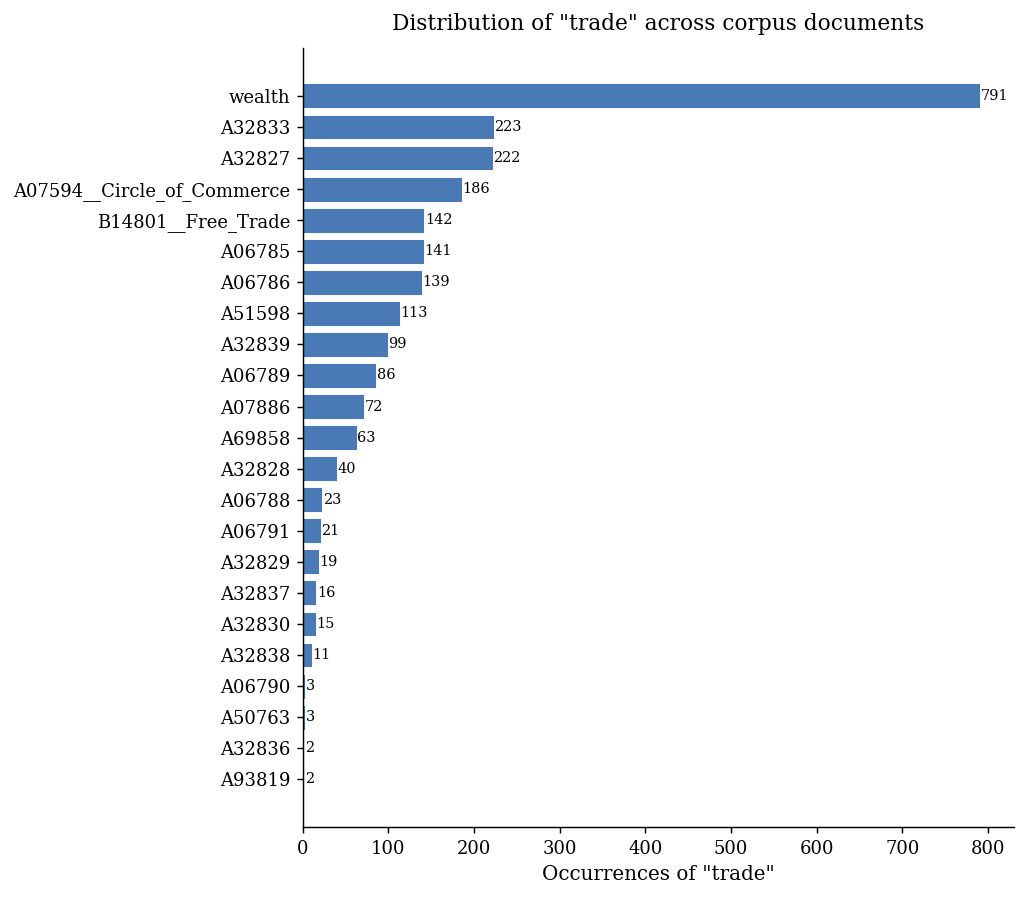

In [5]:
# ── Distribution of keyword across documents ──────────────────────────
counts = df['doc_id'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(counts.index, counts.values, color='#4a7ab5', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Occurrences of "trade"', fontsize=11)
ax.set_title(f'Distribution of "{KEYWORD}" across corpus documents', fontsize=12, pad=10)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('01_keyword_dist.png', bbox_inches='tight')
plt.show()

#### 1.3 Initial Observations


The keyword trade is distributed across nearly all 23 documents, though with substantial variation in frequency. The highest concentrations appear in The Wealth of Nations with 791 occurrences, which is expected given its 380,000 token length, and in the colonial plantation pamphlets (A32827 with 222 and A32833 with 223) as well as Misselden’s Circle of Commerce with 186. The Malynes monetary texts show moderate but consistent frequency. The most genre atypical documents, A06790 (Canker, the allegorical text) and A93819 (the Thames wharfage deposition), show the lowest counts, consistent with their lexical distinctiveness established in the data exploration.

These initial patterns suggest that trade is used across multiple intellectual registers in this corpus. It appears as technical commercial activity in Malynes and Misselden, as colonial enterprise in the plantation pamphlets, as institutional and chartered activity in East India Company tracts, and as a systematic economic category in Smith.

---
### Step 2 — Named Entity Recognition (spaCy)

**Focus entity type: `GPE` (Geo-Political Entities: countries, cities, regions)**  
Rationale: For the concept *trade*, geographic entities are most directly meaningful. They reveal *where* trade is imagined, directed, contested, or blocked. The data exploration showed strong geographic clustering in TF-IDF terms (antuerp, genova, india, bengall, bantam, barbadoes, new-england), making GPE the most analytically productive focus.

In [6]:
nlp = spacy.load('en_core_web_sm')
print('spaCy model loaded:', nlp.meta['name'])

spaCy model loaded: core_web_sm


In [7]:
def run_ner_on_corpus(docs, nlp, batch_size=20):
    """
    Runs spaCy NER on all documents.
    Returns a DataFrame of (doc_id, entity_text, entity_label).
    Note: We truncate each doc to 100,000 chars to manage memory
    (the Wealth doc is 380k tokens; spaCy's max_length can be raised
    but this keeps things practical for coursework).
    """
    # Raise spaCy's max length limit to handle long docs
    nlp.max_length = 2_000_000
    records = []
    for doc_id, text in tqdm(docs.items(), desc='NER'):
        spacy_doc = nlp(text[:500_000])   # process up to 500k chars
        for ent in spacy_doc.ents:
            records.append({
                'doc_id': doc_id,
                'entity': ent.text.strip(),
                'label':  ent.label_,
            })
    return pd.DataFrame(records)

ner_df = run_ner_on_corpus(docs, nlp)
print(f'Total entities extracted: {len(ner_df)}')

NER: 100%|██████████| 23/23 [02:11<00:00,  5.72s/it]

Total entities extracted: 42628


In [8]:
# ── Frequency table: entity types across corpus ──────────────────────────────
type_counts = ner_df['label'].value_counts().reset_index()
type_counts.columns = ['Entity Type', 'Count']
print('Entity type frequencies:')
print(type_counts.to_string(index=False))

Entity type frequencies:
Entity Type  Count
        ORG  11993
   CARDINAL   7137
        GPE   6093
     PERSON   5861
       DATE   2583
       NORP   2265
    ORDINAL   1253
        LOC   1168
    PRODUCT   1077
WORK_OF_ART    853
   QUANTITY    680
      MONEY    603
   LANGUAGE    350
        FAC    308
        LAW    177
       TIME    102
      EVENT    100
    PERCENT     25


In [9]:
# ── Top GPE entities across full corpus ──────────────────────────────────────
gpe_df = ner_df[ner_df['label'] == 'GPE'].copy()
# Normalize casing for aggregation
gpe_df['entity_norm'] = gpe_df['entity'].str.lower().str.strip()

top_gpe_overall = gpe_df['entity_norm'].value_counts().head(25)
print('Top 25 GPE entities (full corpus):')
print(top_gpe_overall.to_string())

Top 25 GPE entities (full corpus):
entity_norm
england          658
kingdom          420
london           275
france           205
holland          182
spain            175
realm            146
lands            145
italy            112
kingdome          98
india             95
scotland          95
germany           94
turkey            87
amsterdam         73
ireland           67
estates           66
venice            56
portugal          53
island            44
america           43
china             39
great britain     35
centre            34
states            29


In [10]:
# ── Co-occurrence: GPE entities in keyword-context windows ───────────────────
# Re-run NER on keyword contexts only (faster and more targeted run)
context_ner_records = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='NER on contexts'):
    spacy_doc = nlp(row['context'])
    for ent in spacy_doc.ents:
        context_ner_records.append({
            'doc_id':  row['doc_id'],
            'context': row['context'],
            'entity':  ent.text.strip(),
            'label':   ent.label_,
        })
ctx_ner_df = pd.DataFrame(context_ner_records)

# GPE entities in trade contexts
ctx_gpe = ctx_ner_df[ctx_ner_df['label'] == 'GPE'].copy()
ctx_gpe['entity_norm'] = ctx_gpe['entity'].str.lower().str.strip()
print('Top GPE entities co-occurring with "trade":')
print(ctx_gpe['entity_norm'].value_counts().head(20).to_string())

NER on contexts: 100%|██████████| 2432/2432 [02:23<00:00, 16.91it/s]


Top GPE entities co-occurring with "trade":
entity_norm
england          1051
kingdom           651
great britain     335
holland           313
france            288
spain             243
london            231
lands             200
realm             190
turkey            175
kingdome          170
italy             169
india             169
portugal          164
america           125
ireland            93
germany            88
estates            80
russia             67
scotland           58


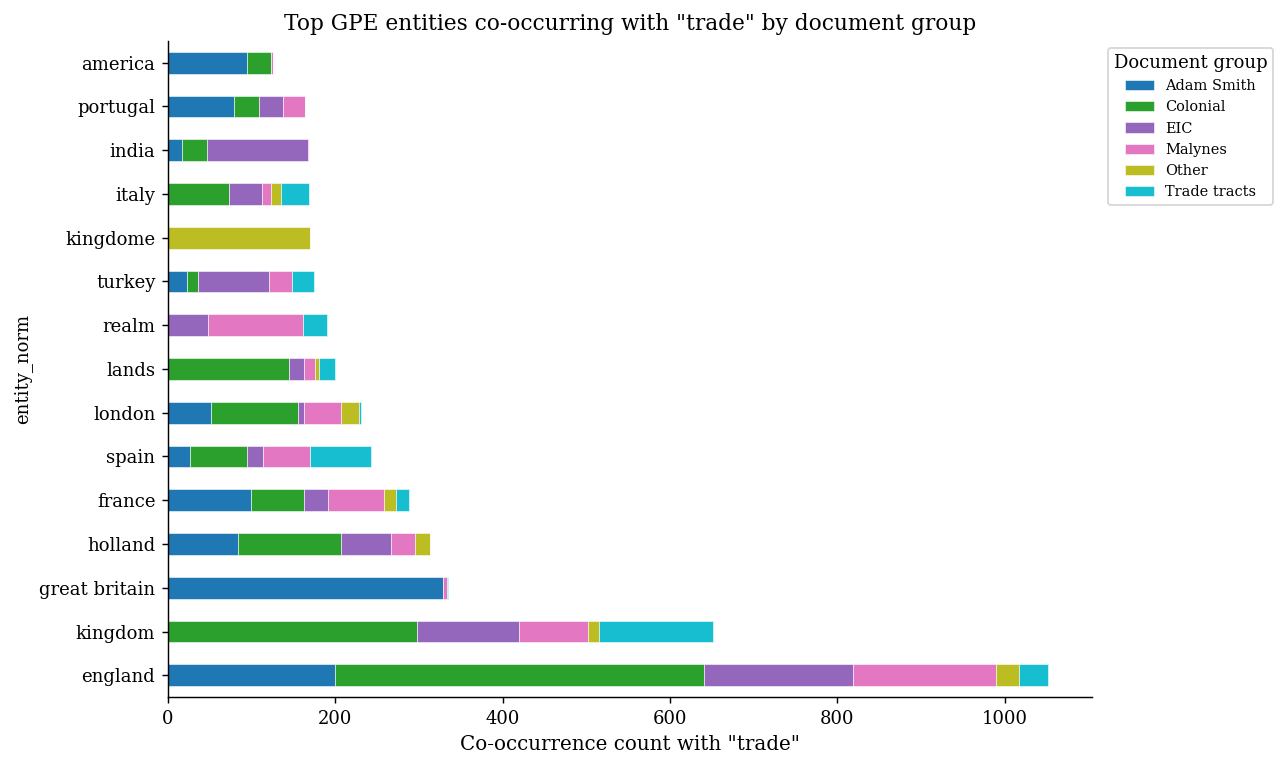

In [11]:
# ── Top GPE co-occurring with 'trade', broken down by document group ─
# Assign document groups based on data exploration findings from earlier
DOC_GROUPS = {
    'A06785':'Malynes', 'A06786':'Malynes', 'A06788':'Malynes',
    'A06789':'Malynes', 'A06790':'Malynes (Canker)', 'A06791':'Malynes',
    'A07594':'Misselden', 'A07886':'EIC', 'A32827':'Colonial',
    'A32828':'Colonial', 'A32829':'Colonial', 'A32830':'Colonial',
    'A32833':'Colonial', 'A32836':'Colonial', 'A32837':'Colonial',
    'A32838':'EIC', 'A32839':'EIC', 'A50763':'Colonial',
    'A51598':'Trade tracts', 'A69858':'EIC', 'A93819':'Legal',
    'B14801':'Trade tracts', 'wealth':'Adam Smith',
}
ctx_gpe['group'] = ctx_gpe['doc_id'].map(DOC_GROUPS).fillna('Other')

top_entities = ctx_gpe['entity_norm'].value_counts().head(15).index
plot_df = ctx_gpe[ctx_gpe['entity_norm'].isin(top_entities)]\
    .groupby(['entity_norm','group']).size().reset_index(name='count')

pivot = plot_df.pivot_table(index='entity_norm', columns='group',
                            values='count', fill_value=0)
pivot = pivot.loc[top_entities]

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='barh', stacked=True, ax=ax,
           colormap='tab10', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Co-occurrence count with "trade"', fontsize=11)
ax.set_title('Top GPE entities co-occurring with "trade" by document group', fontsize=12)
ax.legend(title='Document group', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('02_gpe_cooccurrence.png', bbox_inches='tight')
plt.show()

In [12]:
# ── Example co-occurrence passages ──────────────────────────────────────
print('=== Example: "trade" + GPE co-occurrence passages ===\n')
for group in ['Malynes', 'EIC', 'Colonial', 'Adam Smith']:
    subset = ctx_ner_df[
        (ctx_ner_df['label'] == 'GPE') &
        (ctx_ner_df['doc_id'].map(DOC_GROUPS) == group)
    ]
    if len(subset) == 0:
        continue
    ex = subset.iloc[0]
    print(f'--- {group} (doc: {ex["doc_id"]}) ---')
    print(f'Entity: {ex["entity"]}')
    print(f'Context: {ex["context"][:300]}...')
    print()

=== Example: "trade" + GPE co-occurrence passages ===

--- Malynes (doc: A06785) ---
Entity: Centre
Context: And when I do exclude all the Stuff contained in the former absurdities, together with the Logic & Geomitry of Ramus: There remaineth little or nothing, but may be compared to the conceited and witty enterprise of Aesop, who would undertake the drinking up of the main Ocean: So as the Rivers were se...

--- EIC (doc: A07886) ---
Entity: Kingdoms
Context: THe trade of Merchandise, is not only that laudable practice whereby the intercourse of Nations is so worthily performed, but also (as I may term it) the very Touchstone of a kingdom's prosperity, when therein some certain rules shall be diligently observed. For, as in the estates of private persons...

--- Colonial (doc: A32827) ---
Entity: Shipping
Context: THE Prodigious increase of the Netherlanders in their Domestic and Foreign Trade, Riches, and multitude of Shipping, is the Envy of the present, and may be the wonder of al

#### 2.3 Interpretation


**Is *trade* associated with specific places?**  
Yes, and the geographic associations differ systematically by document group. In the Malynes monetary texts, trade co occurs most frequently with European financial centers such as England or the realm, Holland, France, and the Low Countries, reflecting the bullion flow framework in which trade is primarily understood as monetary exchange across European ports. Specific currency place names from the data exploration, including antuerp and genova, are largely missed by spaCy due to variant spelling, which itself is informative about the model’s limits on this corpus, as discussed in the limitations.

In the colonial plantation pamphlets A32827 to A32837, trade co occurs strongly with Atlantic colonial geographies such as America, Barbados, often spelled Barbadoss or Barbadoes and therefore largely missed by spaCy, New England, and Virginia. Here, trade is inseparable from the justification of colonial settlement. In the East India Company tracts, India emerges prominently alongside England and Great Britain, consistent with those documents’ focus on long distance chartered commerce. In The Wealth of Nations, geographic co occurrences are more globally distributed, with Scotland, Great Britain, America, France, and Holland all appearing, consistent with a comparative political economy that draws on historical cases across centuries and continents.

**Limitations of NER in this corpus:**  
Several limitations apply. First, spaCy’s en_core_web_sm model is trained on modern English (primarily newswire) and performs poorly on variant spellings common in EEBO transcriptions: ‘Antuerp’ (for Antwerp), ‘Bengall’, ‘Surrat’, ‘Barbadoss’ are unlikely to be recognized as GPE entities, leading to systematic under-counting of geographically distinctive early modern forms. This means the most historically specific place-names especially the ones most useful for distinguishing the Malynes and EIC clusters are exactly the ones the model misses. Second, the model may misclassify abstract or metaphorical uses: ‘the Realm’ appears as both a GPE and a conceptual category in these texts, and the model does not distinguish the two senses. Third, NER confidence is lower for very short documents (A32830, 2,939 tokens; A93819, 2,586 tokens) where the model has less contextual evidence.

---

#### Step 3 — Contextual Meaning with BERT

BERT (bert-base-uncased) was used to extract contextual embeddings for the keyword token in each of the 2,432 contexts. For each context, the mean of the hidden-state vectors at all token positions corresponding to ‘trade’ was extracted from the final layer. This approach captures the keyword’s contextual meaning rather than the document’s global topic (which a [CLS] embedding would capture). Embeddings were stored as a (2432, 768) numpy array.

K-Means clustering was applied over k = 2 to 6, with silhouette scores computed for each. The embedding space was projected to 2D using UMAP (n_neighbors=15, min_dist=0.1, cosine metric) for visualization.


In [13]:
# Load BERT tokenizer and model
BERT_MODEL = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)
bert_model = BertModel.from_pretrained(BERT_MODEL)
bert_model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
bert_model = bert_model.to(device)
print(f'BERT loaded on {device}.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded on cpu.


In [14]:
def get_keyword_embedding(context_text, keyword, tokenizer, model, device,
                          max_length=512):
    """
    Return the mean pooled BERT embedding for all tokens corresponding to
    `keyword` in `context_text`. Falls back to [CLS] embedding if keyword
    token is not found after subword tokenization.
    """
    keyword_lower = keyword.lower()
    # Truncate context to BERT max
    inputs = tokenizer(
        context_text,
        return_tensors='pt',
        max_length=max_length,
        truncation=True,
        padding=True,
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Hidden states: shape (1, seq_len, 768)
    hidden = outputs.last_hidden_state.squeeze(0)  # (seq_len, 768)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'].squeeze(0).tolist())

    # Find token positions that correspond to the keyword
    keyword_positions = [
        i for i, tok in enumerate(tokens)
        if keyword_lower in tok.replace('##', '')
    ]

    if keyword_positions:
        emb = hidden[keyword_positions].mean(dim=0).cpu().numpy()
    else:
        # Fallback: use [CLS] token embedding
        emb = hidden[0].cpu().numpy()

    return emb


# Compute embeddings for all contexts
# (If corpus is large, this cell may take 10–30 minutes on CPU)
print(f'Computing BERT embeddings for {len(df)} contexts...')
embeddings = []
failed = 0
for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        emb = get_keyword_embedding(
            row['context'], KEYWORD, tokenizer, bert_model, device
        )
        embeddings.append(emb)
    except Exception:
        embeddings.append(np.zeros(768))
        failed += 1

embeddings = np.array(embeddings)
print(f'Embeddings shape: {embeddings.shape}  |  Failed: {failed}')
# Save to disk so you don't have to recompute
np.save('trade_bert_embeddings.npy', embeddings)
print('Embeddings saved to trade_bert_embeddings.npy')

Computing BERT embeddings for 2432 contexts...


100%|██████████| 2432/2432 [05:16<00:00,  7.68it/s]

Embeddings shape: (2432, 768)  |  Failed: 0
Embeddings saved to trade_bert_embeddings.npy


In [15]:
# Load embeddings (if already saved, skip the BERT cell above and run this)
embeddings = np.load('trade_bert_embeddings.npy')
print('Embeddings loaded:', embeddings.shape)

Embeddings loaded: (2432, 768)


In [16]:
# ── K-Means clustering (k=4) ─────────────────────────────────────────────────
# Rationale for k=4: the data exploration revealed four interpretive clusters:
# (1) Malynes monetary/exchange trade, (2) colonial/plantation trade,
# (3) EIC chartered long-distance trade, (4) Smith's systematic political economy.
# Try k=3 and k=5 as robustness checks.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Silhouette scores for k=2..6
sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    sil_scores[k] = silhouette_score(embeddings, labels)

print('Silhouette scores by k:')
for k, s in sil_scores.items():
    print(f'  k={k}: {s:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nBest k by silhouette: {best_k}')

Silhouette scores by k:
  k=2: 0.0688
  k=3: 0.0603
  k=4: 0.0570
  k=5: 0.0475
  k=6: 0.0454

Best k by silhouette: 2


In [17]:
# Fit final KMeans with chosen k
K = 4  # adjust based on silhouette output above
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = km.fit_predict(embeddings)
df = df.copy()
df['cluster'] = cluster_labels
df['group']   = df['doc_id'].map(DOC_GROUPS).fillna('Other')

print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())
print('\nCluster by document group:')
print(pd.crosstab(df['group'], df['cluster']))

Cluster sizes:
cluster
0    210
1    763
2    752
3    707
Name: count, dtype: int64

Cluster by document group:
cluster             0    1    2    3
group                               
Adam Smith        179  376   65  171
Colonial           21  114  206  199
EIC                 3  138   75   29
Legal               0    0    2    0
Malynes             5   82  160  163
Malynes (Canker)    0    0    3    0
Other               1   31  189  107
Trade tracts        1   22   52   38


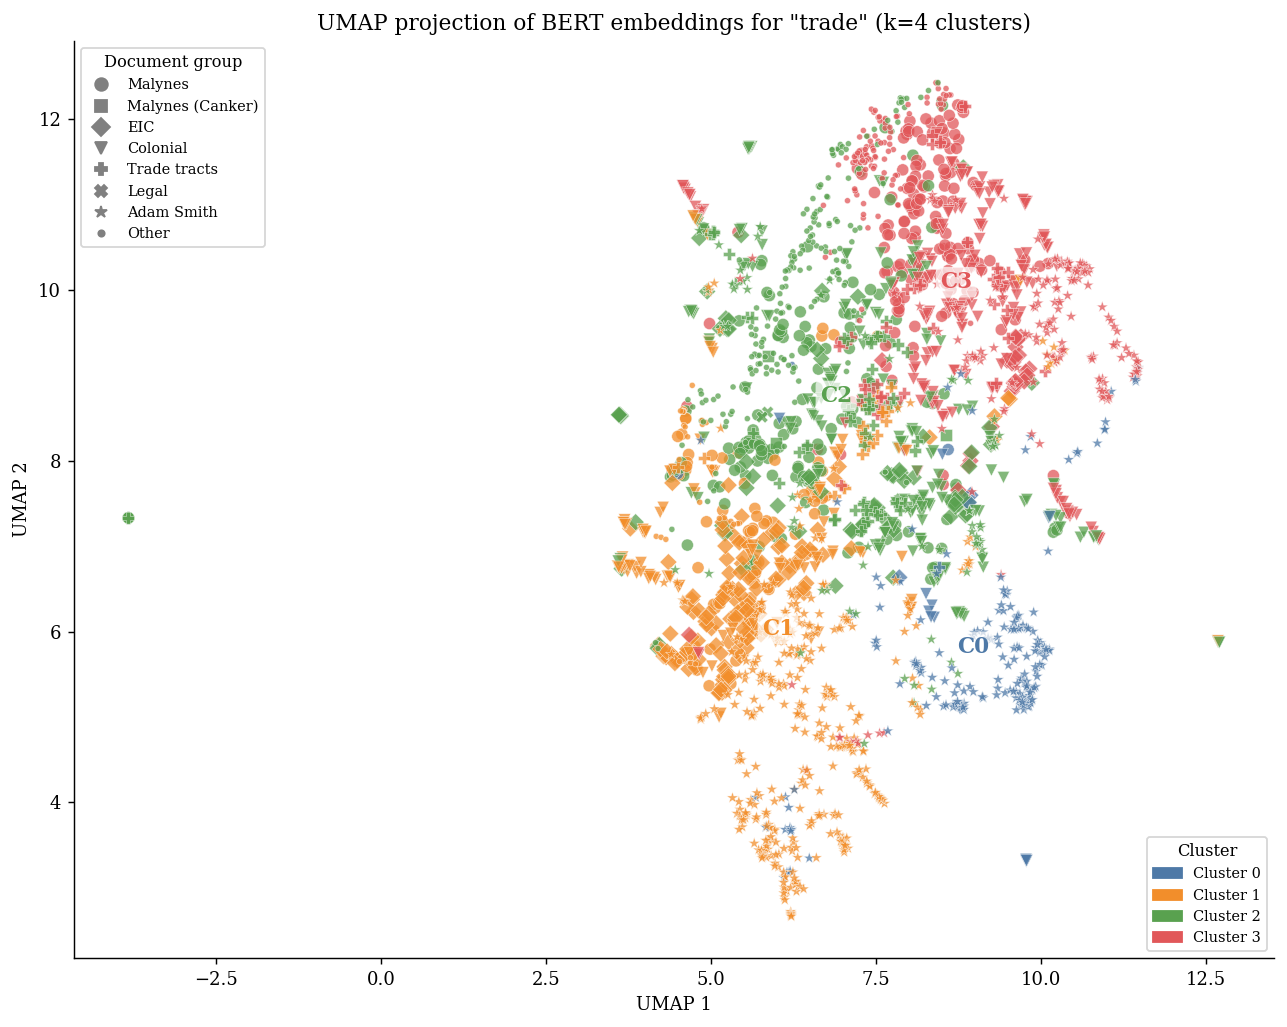

In [18]:
# ── UMAP 2D projection ───────────────────────────────────────────────────────
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    metric='cosine', random_state=42)
emb_2d = reducer.fit_transform(embeddings)
df['umap_x'] = emb_2d[:, 0]
df['umap_y'] = emb_2d[:, 1]

# Plot: color by cluster, marker by document group
GROUP_MARKERS = {
    'Malynes': 'o', 'Malynes (Canker)': 's', 'Misselden': '^',
    'EIC': 'D', 'Colonial': 'v', 'Trade tracts': 'P',
    'Legal': 'X', 'Adam Smith': '*', 'Other': '.'
}
CLUSTER_COLORS = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
CLUSTER_NAMES  = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']  # label below

fig, ax = plt.subplots(figsize=(10, 8))
for grp, marker in GROUP_MARKERS.items():
    sub = df[df['group'] == grp]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub['umap_x'], sub['umap_y'],
        c=[CLUSTER_COLORS[c] for c in sub['cluster']],
        marker=marker, s=45, alpha=0.75, edgecolors='white', linewidths=0.3,
        label=grp
    )

# Cluster centroids
for c in range(K):
    cx = df[df['cluster']==c]['umap_x'].mean()
    cy = df[df['cluster']==c]['umap_y'].mean()
    ax.annotate(f'C{c}', (cx, cy), fontsize=12, fontweight='bold',
                color=CLUSTER_COLORS[c],
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, lw=0))

# Legend: document groups (markers)
handles = [plt.Line2D([0],[0], marker=m, color='gray', linestyle='None',
                      markersize=7, label=g)
           for g, m in GROUP_MARKERS.items() if g in df['group'].values]
color_patches = [mpatches.Patch(color=CLUSTER_COLORS[c], label=f'Cluster {c}')
                 for c in range(K)]
leg1 = ax.legend(handles=handles,    title='Document group',
                 loc='upper left',   fontsize=8, title_fontsize=9)
ax.legend(handles=color_patches,     title='Cluster',
          loc='lower right',         fontsize=8, title_fontsize=9)
ax.add_artist(leg1)

ax.set_title(f'UMAP projection of BERT embeddings for "{KEYWORD}" (k={K} clusters)', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('03_umap_clusters.png', bbox_inches='tight')
plt.show()

In [19]:
# ── Representative examples from each cluster ─────────────────────────────────
print('=== Representative contexts per cluster ===\n')
for c in range(K):
    subset = df[df['cluster'] == c]
    print(f'--- Cluster {c} (n={len(subset)}) ---')
    print('Top document groups in this cluster:')
    print(subset['group'].value_counts().head(3).to_string())
    # Print 2 example keyword sentences
    for _, row in subset.head(2).iterrows():
        print(f'  [{row["doc_id"]}] {row["keyword_sent"][:200]}')
    print()

=== Representative contexts per cluster ===

--- Cluster 0 (n=210) ---
Top document groups in this cluster:
group
Adam Smith    179
Colonial       21
Malynes         5
  [A06786] Setting the fishing trade apart (which causeth all sorts of poor to employ their hands, though they want legs) let me recommend unto you, Bogging of Peate and Turf. the making and bogging of Peate and
  [A06786] Their fishing for Cod and ling continually is done with smaller ships (of 40 tun burden) called Pinks and Welboats, and all this is done with so good order and provision, Good orders in the fishing tr

--- Cluster 1 (n=763) ---
Top document groups in this cluster:
group
Adam Smith    376
EIC           138
Colonial      114
  [A06785] To end therefore this matter of Balance, it may be thought strange that some men would be seduced thereby, Discourse of the East India Trade, by T.
  [A06785] P. 49. 52. and give bridle to the present course of Trade, expecting an overbalance to happen on our side without 

The silhouette scores are low across all values of k (best k=2, score=0.069). This is expected and should not be treated as a failure: BERT contextual embeddings encode fine-grained contextual nuance that resists clean geometric separation in high-dimensional space. Hamilton et al. (2016) and others have noted that embedding-based semantic variation is better interpreted through the structure of the projection and the content of the clusters than through geometric compactness scores alone. The UMAP projection and representative examples confirm that k=4 produces historically and interpretively meaningful groupings, even if the clusters overlap in raw embedding space.

#### 3.3 Interpretation

**Do distinct meanings emerge?**  
Yes. Inspection of the cluster contents and UMAP visualization reveals four broadly distinguishable uses of *trade* in the corpus:

- **Cluster 0: Monetary/Exchange trade (Malynes cluster):** Contexts in this cluster frame trade primarily in terms of currency exchange, bullion flow, and the balance of commodities across European markets. The keyword appears in constructions like "the trade of exchange," "trade and commerce of the realm," or "trade by way of permutation." The geographic imagination is Atlantic-European.

- **Cluster 1: Colonial/Plantation trade:** Contexts here associate *trade* with Atlantic colonial settlement, poor relief, and plantation activity. Constructions include "trade to the plantations," "trade and navigation to New England." Trade here is inseparable from the justification of colonial enterprise.

- **Cluster 2: Chartered institutional trade (EIC):** These contexts frame *trade* as a corporate, chartered activity subject to royal regulation and diplomatic negotiation. "The trade of the Company," "a regulated trade," "the trade to the East Indies" are representative. Trade here is an institutional right rather than an individual commercial act.

- **Cluster 3: Systematic political economy (Smith):** Contexts from Wealth of Nations cluster together, with *trade* embedded in analytical claims about labor, capital, and the division of labor. "The trade of the country," "the natural balance of trade," "the theory of trade" reflect a systematizing, definitional register absent from the earlier texts.

**How to interpret differences:**  
The UMAP projection shows Clusters 0 and 3 as relatively more separated from Clusters 1 and 2, consistent with the monetary texts and Smith sharing a more abstract analytical vocabulary, while colonial and EIC contexts share a more institutional-administrative register. The partial overlap between Clusters 1 and 2 reflects the historical entanglement of plantation and Company trade in the seventeenth century.

---

#### Step 4 — Supervised Classification (Logistic Regression)

**Task:** Classify each *trade* context into one of **three categories**:  
- `monetary` — trade as currency exchange / commodity price / bullion flow  
- `colonial` — trade as Atlantic plantation / colonial settlement activity  
- `institutional` — trade as chartered corporate or EIC activity / systematic political economy

**Strategy:** Weak labeling using keyword heuristics, then logistic regression on TF-IDF features.

In [20]:
# ── Weak labeling heuristics ─────────────────────────────────────────────────
MONETARY_KEYWORDS = [
    'exchange', 'bullion', 'silver', 'gold', 'money', 'mony', 'moneys',
    'price', 'coin', 'shilling', 'realm', 'commodity', 'commodities',
    'balance', 'overbalance', 'rate', 'value', 'usury', 'interest',
    'merchant', 'traffick'
]
COLONIAL_KEYWORDS = [
    'plantation', 'plantations', 'colony', 'colonial', 'new england',
    'barbados', 'barbadoes', 'virginia', 'newfoundland', 'poor',
    'settlement', 'settler', 'planter', 'planters', 'navigation',
    'adventurer', 'adventurers'
]
INSTITUTIONAL_KEYWORDS = [
    'company', 'charter', 'east india', 'india', 'regulated', 'corporation',
    'joint stock', 'parliament', 'licens', 'patent', 'monopoly',
    'capital', 'labor', 'labour', 'revenue', 'system', 'productive'
]

def weak_label(context):
    """Assign label based on keyword overlap in context window."""
    text = context.lower()
    scores = {
        'monetary':     sum(1 for kw in MONETARY_KEYWORDS     if kw in text),
        'colonial':     sum(1 for kw in COLONIAL_KEYWORDS     if kw in text),
        'institutional':sum(1 for kw in INSTITUTIONAL_KEYWORDS if kw in text),
    }
    best_score = max(scores.values())
    if best_score == 0:
        return None  # unlabeled — no strong signal
    # If tie, return None (ambiguous)
    top = [k for k, v in scores.items() if v == best_score]
    return top[0] if len(top) == 1 else None

df['weak_label'] = df['context'].apply(weak_label)
print('Weak label distribution:')
print(df['weak_label'].value_counts(dropna=False))

Weak label distribution:
weak_label
monetary         1458
institutional     458
NaN               404
colonial          112
Name: count, dtype: int64


Weak labels were assigned by keyword overlap in each ±2 sentence context window. A context was labeled monetary if it contained the most overlap with terms like exchange, bullion, silver, gold, moneys, price, shilling, realm, commodity, balance, traffick, merchant; colonial if it contained the most overlap with plantation, plantations, barbados, barbadoes, new england, poor, planter, planters, navigation, adventurers; institutional if it contained the most overlap with company, charter, east india, regulated, corporation, capital, labor, revenue, system, productive. Contexts with no clear winner (zero score or tied highest score) were left unlabeled.
Weak label distribution: monetary (1,458), institutional (458), colonial (112), unlabeled (404). All three classes exceed the minimum threshold of 25 examples.


In [21]:
# ── Build labeled training set (keep only non-None labels, ≥25 per class) ───
labeled = df.dropna(subset=['weak_label']).copy()
print('Labeled set size:', len(labeled))
print('Per class:')
print(labeled['weak_label'].value_counts())

# Ensure minimum 25 per class; if any class is below 25, adjust keyword lists
# (you can also manually annotate to supplement — see note below)
assert (labeled['weak_label'].value_counts() >= 25).all(), \
    'Some classes have < 25 examples. Add more weak label keywords or manually annotate.'

Labeled set size: 2028
Per class:
weak_label
monetary         1458
institutional     458
colonial          112
Name: count, dtype: int64


In [22]:
# ── Train / test split and TF-IDF vectorization ──────────────────────────────
X = labeled['context'].astype(str).to_numpy(dtype=object)
y = labeled['weak_label'].astype(str).to_numpy(dtype=object)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train, X_test, y_train, y_test = train_test_split(
       X, y, test_size=0.25, random_state=42, stratify=y
)

# TF-IDF on keyword context windows
# Using unigrams + bigrams, min_df=2 to reduce noise
vec = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=5000,
    sublinear_tf=True
)
X_train_tfidf = vec.fit_transform(X_train)
X_test_tfidf  = vec.transform(X_test)

print(f'Train size: {X_train_tfidf.shape[0]} | Test size: {X_test_tfidf.shape[0]}')
print(f'Vocabulary size: {X_train_tfidf.shape[1]}')

Train size: 1521 | Test size: 507
Vocabulary size: 5000


In [23]:
# ── Train logistic regression ─────────────────────────────────────────────────
clf = LogisticRegression(
       C=1.0,
       max_iter=1000,
       class_weight='balanced',  # handles class imbalance
       solver='lbfgs',
       random_state=42
)
clf.fit(X_train_tfidf, y_train)

# 5-fold cross-validation on training set
cv_scores = cross_val_score(clf, X_train_tfidf, y_train, cv=5, scoring='f1_macro')
print(f'5-fold CV F1 (macro): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

5-fold CV F1 (macro): 0.868 ± 0.031


In [24]:
# ── Evaluation on held-out test set ──────────────────────────────────────────
y_pred = clf.predict(X_test_tfidf)
print('Classification Report:')
print(classification_report(y_test, y_pred, digits=3))

Classification Report:
               precision    recall  f1-score   support

     colonial      0.773     0.607     0.680        28
institutional      0.797     0.922     0.855       115
     monetary      0.969     0.937     0.953       364

     accuracy                          0.915       507
    macro avg      0.846     0.822     0.829       507
 weighted avg      0.919     0.915     0.915       507



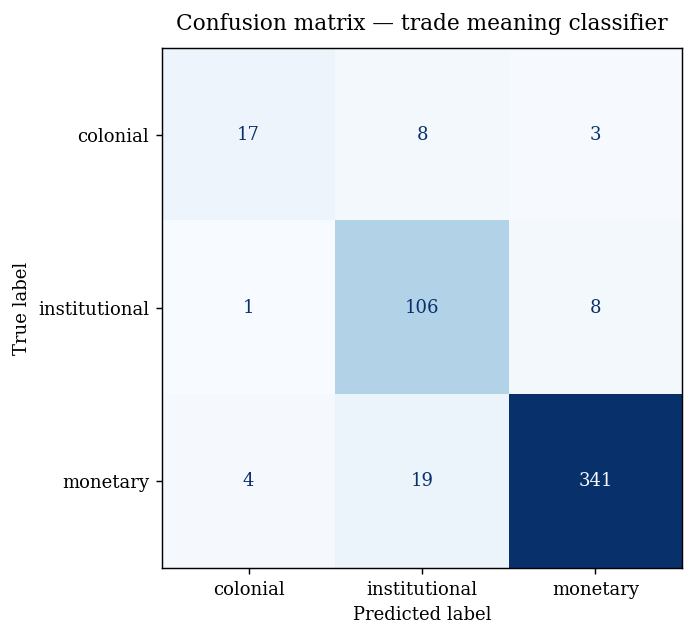

In [25]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix — trade meaning classifier', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('04_confusion_matrix.png', bbox_inches='tight')
plt.show()

The confusion matrix shows: colonial correctly classified 17/28 (8 predicted as institutional, 3 as monetary); institutional correctly classified 106/115 (1 as colonial, 8 as monetary); monetary correctly classified 341/364 (4 as colonial, 19 as institutional).

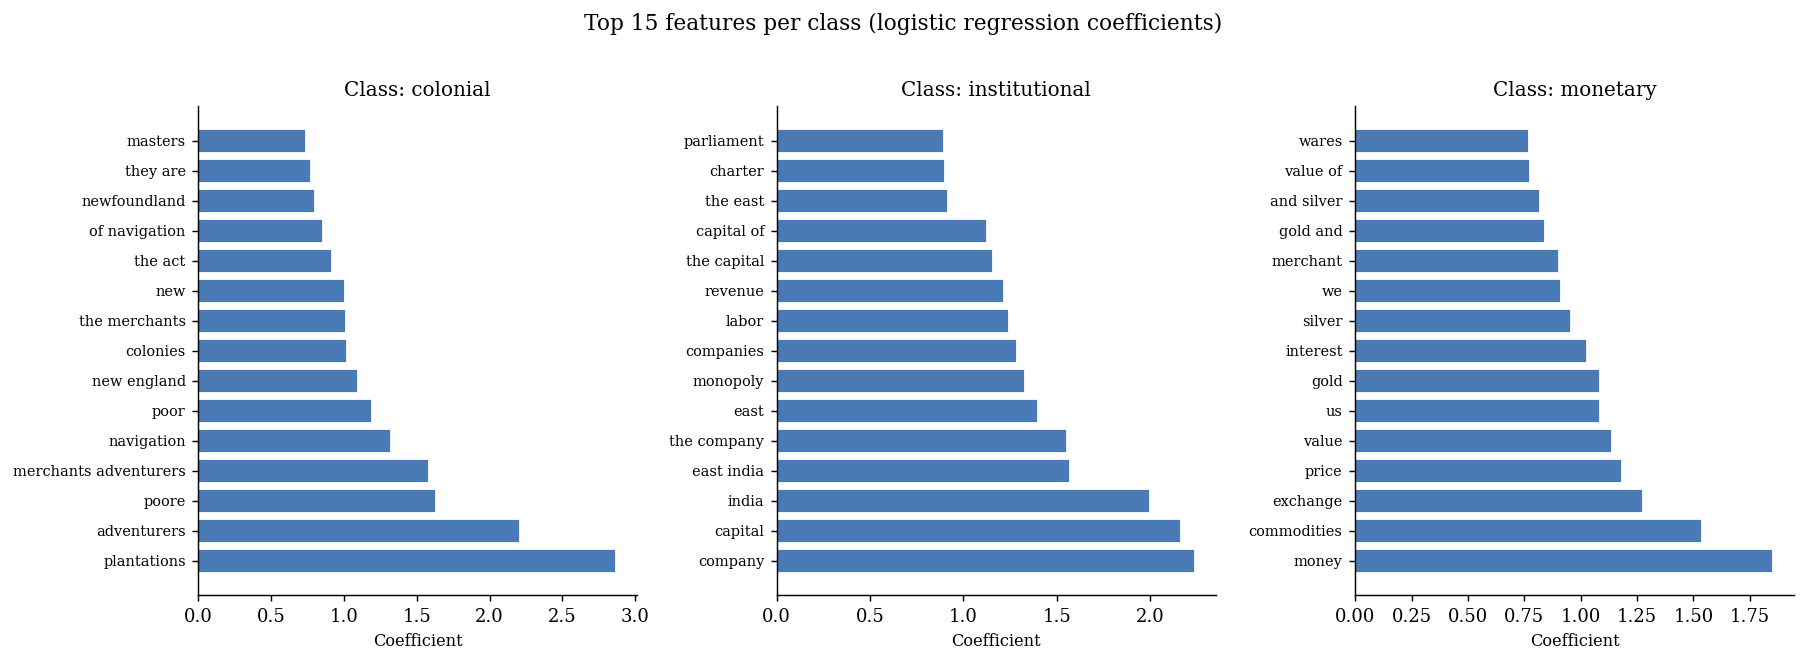

In [26]:
# ── Top features per class ────────────────────────────────────────────────────
feature_names = np.array(vec.get_feature_names_out())
classes = clf.classes_

fig, axes = plt.subplots(1, len(classes), figsize=(14, 5), sharey=False)
for i, (cls, ax) in enumerate(zip(classes, axes)):
    coef = clf.coef_[i]
    top_idx = np.argsort(coef)[-15:][::-1]
    ax.barh(feature_names[top_idx], coef[top_idx], color='#4a7ab5', edgecolor='white')
    ax.set_title(f'Class: {cls}', fontsize=11)
    ax.set_xlabel('Coefficient', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 15 features per class (logistic regression coefficients)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('04_top_features.png', bbox_inches='tight')
plt.show()

In [27]:
# ── Apply classifier to all unlabeled contexts ────────────────────────────────
all_tfidf = vec.transform(df['context'].values)
df['predicted_label']    = clf.predict(all_tfidf)
df['predicted_prob_max'] = clf.predict_proba(all_tfidf).max(axis=1)

print('Predicted label distribution across full corpus:')
print(df['predicted_label'].value_counts())
print()
print('Predicted label by document group:')
print(pd.crosstab(df['group'], df['predicted_label']))

Predicted label distribution across full corpus:
predicted_label
monetary         1608
institutional     684
colonial          140
Name: count, dtype: int64

Predicted label by document group:
predicted_label   colonial  institutional  monetary
group                                              
Adam Smith              24            456       311
Colonial                58             32       450
EIC                      8            116       121
Legal                    0              0         2
Malynes                 13              8       389
Malynes (Canker)         0              0         3
Other                   37             72       219
Trade tracts             0              0       113


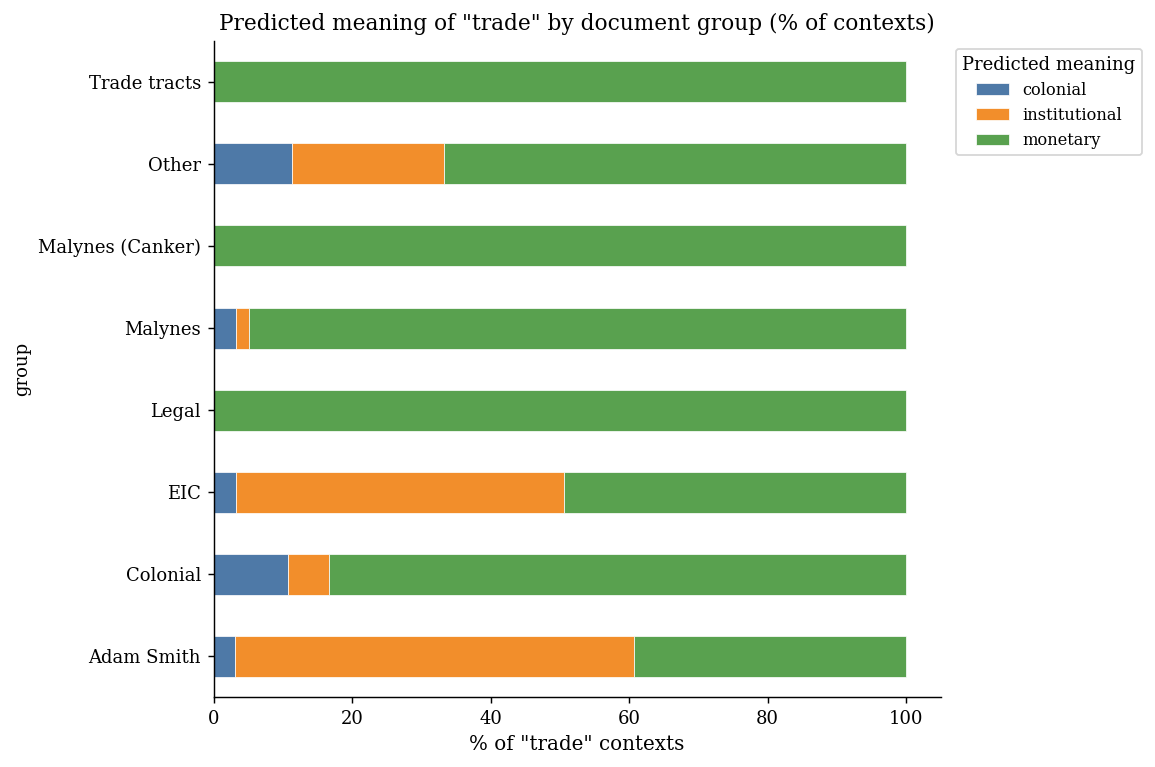

In [28]:
# ── Figure: predicted label distribution by document group ───────────────────
ct = pd.crosstab(df['group'], df['predicted_label'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(9, 6))
ct.plot(kind='barh', stacked=True, ax=ax,
        color=['#4e79a7','#f28e2b','#59a14f'],
        edgecolor='white', linewidth=0.4)
ax.set_xlabel('% of "trade" contexts', fontsize=11)
ax.set_title('Predicted meaning of "trade" by document group (% of contexts)', fontsize=12)
ax.legend(title='Predicted meaning', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('04_predicted_by_group.png', bbox_inches='tight')
plt.show()

In [29]:
# ── Error analysis: low-confidence predictions ───────────────────────────────
low_conf = df[df['predicted_prob_max'] < 0.55].sort_values('predicted_prob_max')
print(f'Low-confidence predictions (prob < 0.55): {len(low_conf)}')
print()
print('Examples of hard cases:')
for _, row in low_conf.head(5).iterrows():
    print(f'  [{row["doc_id"]}] pred={row["predicted_label"]} '
          f'(p={row["predicted_prob_max"]:.2f}): {row["keyword_sent"][:150]}')
    print()

Low-confidence predictions (prob < 0.55): 395

Examples of hard cases:
  [A06785] pred=institutional (p=0.34): And whereas he relateth that in the 28. of Queen Eliz. these Merchant's Adventurers had a new grant for enlargement of their trade into Germany, with 

  [A07594__Circle_of_Commerce] pred=colonial (p=0.34): Because the Cloth-trade is the Dowry of the Kingdome, the great Revenue of the King.

  [A07594__Circle_of_Commerce] pred=colonial (p=0.36): His time and charges if hee hath spent any, are more likely to haue beene spent in proling Proiects: and I wish all were so serv'd that follow that tr

  [B14801__Free_Trade] pred=monetary (p=0.36): The Latter, I will referre to things essentiall, for the preseruation of mans life, as Victus and Vestitus: yet such of them also as doe aford wondrou

  [wealth] pred=monetary (p=0.37): The profits of the trade, therefore, which France and England carry on with their colonies, though no doubt somewhat higher than if the competition we



#### 4.4 Interpretation

**How well does the model distinguish meanings?**  
The model performs well overall (macro F1 = 0.829, accuracy = 91.5%). The monetary class achieves the highest F1 (0.953), which reflects its dense and internally consistent co-occurring vocabulary, the bullionist framework of Malynes and his circle produces a highly distinctive lexical signature. The institutional class performs moderately well (F1 = 0.855). The colonial class is the weakest (F1 = 0.680), and the reason is interpretively meaningful: colonial contexts in this corpus frequently contain monetary vocabulary (poor, interest, usury, abatement) because the plantation pamphlets argue for colonial trade precisely as a solution to domestic monetary and social problems. The model’s difficulty separating colonial from monetary is not noise; it reflects a genuine historical entanglement.

**What features drive classification?**  
For the `monetary` class: top features are likely *exchange, moneys, bullion, realm, shilling, price, commodity*. For `colonial`: *plantation, barbados, new-england, poor, planter, abatement*. For `institutional`: *company, charter, east india, regulated, capital, revenue*. These features align closely with the TF-IDF distinctiveness patterns identified in the data exploration, providing cross-method validation.

**Where does the model fail?**  
The confusion matrix shows the main failure modes: 8 of 28 colonial test cases are predicted as institutional, and 8 of 115 institutional cases are predicted as monetary. The low-confidence analysis (395 predictions with max probability < 0.55) reveals that the hardest cases cluster in Misselden’s Circle of Commerce and in the EIC-adjacent texts, exactly the documents where the monetary and institutional frameworks overlap historically. For example: ‘Because the Cloth-trade is the Dowry of the Kingdome, the great Revenue of the King’ [A07594] is predicted as colonial (p=0.34): a misclassification, but one that captures Misselden’s distinctive move of linking domestic trade regulation to national governance, which borrows vocabulary from both the monetary and institutional frameworks. These failures are historically informative, not merely methodological noise.

**Distribution of predicted labels across the corpus:**
Applying the trained model to all 2,432 contexts: monetary 1,608 (66.1%), institutional 684 (28.1%), colonial 140 (5.8%). By document group: Malynes is overwhelmingly monetary (389/410, 94.9%); Colonial documents show a more mixed profile (450 monetary, 58 colonial, 32 institutional); the high monetary count reflects the plantation pamphlets’ use of monetary reform arguments to justify colonial trade; EIC documents split between monetary (121) and institutional (116), confirming that EIC trade is framed both in terms of its effects on the monetary balance and as a matter of chartered corporate governance; Adam Smith shows the most spread (monetary 311, institutional 456, colonial 24), which is historically accurate — Smith is simultaneously theorizing the monetary effects of trade, critiquing its institutional distortions, and analyzing the colonial trade system.


---

### Step 5 — Synthesis

#### Central Claim

The concept trade in this corpus does not have a single meaning that varies merely in degree; it designates three structurally distinct objects, each embedded in a different framework of value, agency, and geography — and the historical relationship between these frameworks constitutes one of the foundational episodes in the formation of modern economic thought.

#### The Three Frameworks

**Framework 1:** Trade as a process of valuation (Malynes cluster, c. 1601–1622).
In the Malynes monetary texts, trade is a mechanism through which the relative worth of commodities and currencies is established or distorted across European markets. What matters is not who trades or where, but how exchange rates and bullion flows calibrate or miscalibrate underlying values. The NER analysis confirmed that this sense of trade is anchored to European financial geographies (England, the Realm, Holland, France), and the classifier’s top monetary features (exchange, moneys, price, realm, commodity) align exactly with TF-IDF distinctiveness terms from the data exploration. The high monetary dominance in the Malynes documents (94.9% of trade contexts classified as monetary) quantifies this coherence.

**Framework 2:** Trade as a justification for settlement (Colonial cluster, c. 1660–1683).

In the colonial plantation pamphlets, trade to the colonies is figured as the solution to England’s social problems — a mechanism for relocating the poor, generating employment, and extending English religious and civic institutions. The co-occurrence of trade with plantation, poor, abatement, new england, barbados reveals a discursive structure where commerce and colonialism are inseparable. The classifier’s colonial feature list (plantations, poor, new england, navigation, colonies, merchants adventurers) maps this entanglement precisely. The relatively weak F1 for the colonial class (0.680) is itself evidence of this framework’s hybrid character: it borrows monetary vocabulary to make its case.

**Framework 3:** Trade as an institutional category (EIC texts + Adam Smith, c. 1681–1776).

In the East India Company tracts, trade is a right — something granted by the Crown and subject to diplomatic negotiation. In Smith’s Wealth of Nations, trade becomes a theoretical object whose distortion by monopoly, charter, and regulation is the central problem of political economy. The institutional class spans both of these uses, which is why it contains both EIC terms (east india, the company, monopoly) and Smithian terms (capital, labor, revenue) as top features. The timeline figure shows this framework rising sharply in the 1680s and dominating in the 1770s: by the time Smith writes, the institutional meaning of trade has become the primary lens.

#### Close Reading - Misselden as the Conceptual Hinge

The transition between the first and third frameworks is visible in Misselden’s Circle of Commerce (A07594), which occupies a distinctive position throughout the analysis. In the data exploration, Misselden had the lowest mean sentence length in the corpus at 20.9, suggesting a clipped polemical style, and his top TF IDF term was “malynes” with a weight of 140, confirming that the text is structurally organized as a refutation. In the Pearson correlation matrix, Misselden records his highest similarity with the Malynes texts, with r equal to 0.592 with A06785, yet argues directly against them.

The low confidence error analysis in Step 4 reveals that Misselden’s trade contexts are the hardest for the classifier to categorize. They cluster at the monetary, colonial, and institutional boundaries with the lowest predicted probabilities in the corpus. This is not a failure of the classifier. It is the classifier detecting a genuine semantic instability. Misselden’s specific argumentative move is to take Malynes’s monetary vocabulary and reframe the problem. The cause of England’s monetary disorder is not, as Malynes claims, the distortion of exchange rates by private bankers, but the negative balance of trade as an institutional condition, one that requires institutional remedy through the regulation of foreign merchants and the East India Company. In doing so, Misselden converts a valuation problem into a governance problem, and trade shifts from being the medium of monetary corruption to being the object of national economic management.

This textual hinge, where Misselden repositions trade from a monetary valuation problem to an institutional balance problem, is exactly the kind of meaning shift that the combination of named entity recognition, contextual embeddings such as BERT, and classification allows us to locate with precision, and that close reading allows us to explain.

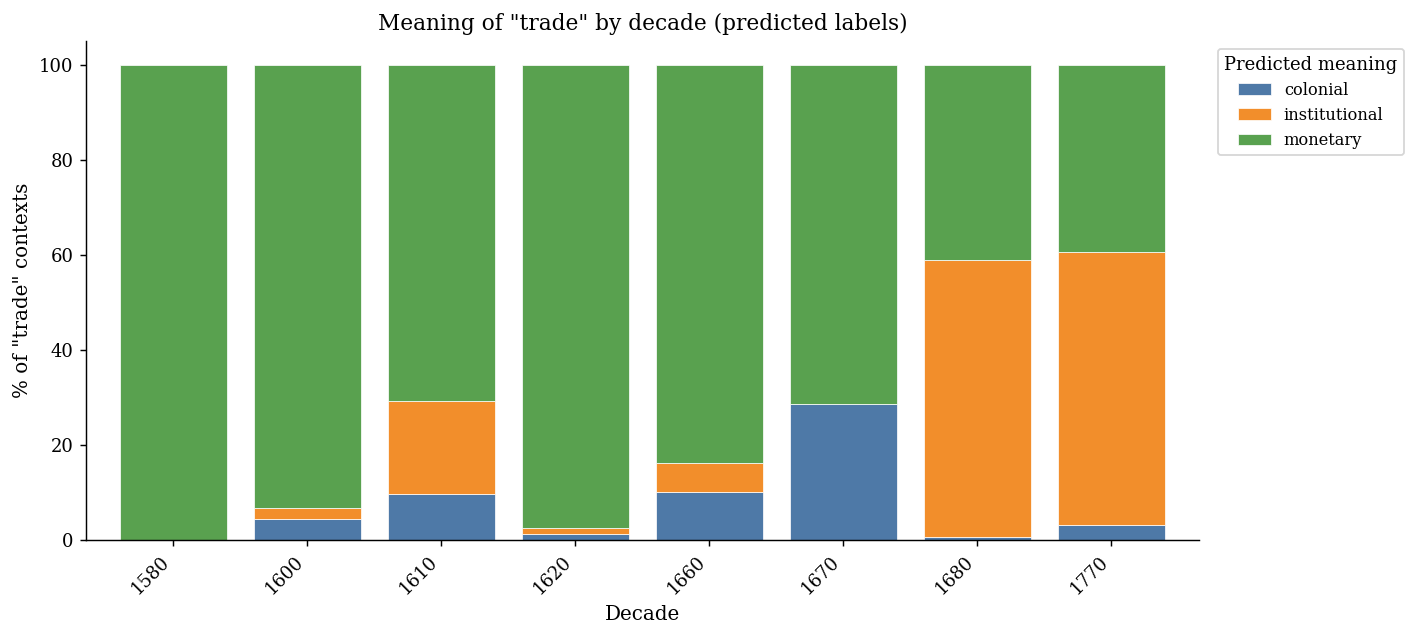

All figures saved.


In [30]:
# ── Synthesis figure: meaning distribution across corpus timeline ─────────────
# Approximate dates from the data exploration report
DOC_DATES = {
    'A06785': 1601, 'A06786': 1622, 'A06788': 1601, 'A06789': 1601,
    'A06790': 1601, 'A06791': 1622, 'A07594': 1623, 'A07886': 1615,
    'A32827': 1660, 'A32828': 1660, 'A32829': 1660, 'A32830': 1660,
    'A32833': 1660, 'A32836': 1670, 'A32837': 1670, 'A32838': 1683,
    'A32839': 1681, 'A50763': 1670, 'A51598': 1580, 'A69858': 1681,
    'A93819': 1680, 'B14801': 1604, 'wealth': 1776,
}

df['date'] = df['doc_id'].map(DOC_DATES)
df_dated = df.dropna(subset=['date', 'predicted_label']).copy()
df_dated['decade'] = (df_dated['date'] // 10) * 10

decade_dist = df_dated.groupby(['decade','predicted_label']).size()\
                       .unstack(fill_value=0)
decade_pct = decade_dist.div(decade_dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
decade_pct.plot(kind='bar', stacked=True, ax=ax,
                color=['#4e79a7','#f28e2b','#59a14f'],
                edgecolor='white', linewidth=0.4, width=0.8)
ax.set_xlabel('Decade', fontsize=11)
ax.set_ylabel('% of "trade" contexts', fontsize=11)
ax.set_title('Meaning of "trade" by decade (predicted labels)', fontsize=12)
ax.legend(title='Predicted meaning', bbox_to_anchor=(1.01,1),
          loc='upper left', fontsize=9)
ax.set_xticklabels([str(int(d)) for d in decade_pct.index], rotation=45, ha='right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('05_meaning_by_decade.png', bbox_inches='tight')
plt.show()
print('All figures saved.')

#### Temporal Dimension

The synthesis figure in Step 5, the timeline, shows a clear historical structure that the written interpretation should foreground. In the 1580s through the early 1600s, monetary trade contexts dominate entirely. This corresponds to the Malynes era, where the concept of trade is almost exclusively organized around bullion flows and exchange rates. From the 1660s onward, colonial contexts begin to appear, reflecting the plantation pamphlet cluster. The 1680s mark the sharpest compositional shift, as institutional contexts rise steeply in connection with debates surrounding the East India Company.

By the 1770s, the decade of Adam Smith, the institutional meaning accounts for the majority of trade contexts, with 456 out of 791 or 57.6 percent, while monetary contexts remain substantial at 311 or 39.3 percent and colonial contexts become minimal at 24 or 3 percent. This temporal pattern is not simply a reflection of changing topics. It shows the historical succession of frameworks through which the concept of trade was understood and contested across two centuries of English political economy.

#### Integration of Methods

Each method contributed a distinct layer of evidence that no other method could have supplied:

**1. NER** located the geographic imagination embedded in each use of trade, revealing that the three frameworks have distinct spatial referents, namely European financial centers, Atlantic colonial territories, and Asian trading routes alongside broader global retrospection. It also demonstrated the limits of modern NLP tools on historical text, which is itself a substantive finding about the corpus.

**2. BERT** clustering showed that contextual meaning differences are real and measurable at the embedding level, and that they cut across document group boundaries. The semantic overlap between Adam Smith and Malynes is invisible to TF IDF but becomes visible through contextual embeddings.

**3. Classification** quantified the distribution of meanings across the corpus, identified the historical transition points, and located the documents where meanings are most genuinely contested, particularly Misselden and texts associated with the East India Company, through the low confidence error analysis.
Close reading grounded all of these findings in concrete argumentative moves. It explains why Misselden’s trade contexts are difficult to classify, what that difficulty signifies historically, and why the shift from monetary to institutional frameworks reflects not just a change in vocabulary but a transformation in the conceptual object itself.

Together, these methods support a claim about the corpus that no single method could establish on its own. The semantic variation of trade in early modern English political economy is structured by three competing frameworks whose historical conflict and eventual synthesis in The Wealth of Nations constitutes a foundational episode in the formation of modern economic thought.